# Tugas - 8 Clustering menggunakan Fuzzy C Means

In [87]:
!pip install fuzzy-c-means
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

In [88]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas-PPWA/Hasil_Prepros.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal
0,"Nunggak 8 Bulan, Segini Pajak Ford Mustang Mil...","Kamis, 19 Sep 2024 13:05 WIB",Jakarta - Bareskrim Polri menyita aset senilai...,Otomotif,Jakarta Bareskrim Polri menyita aset senilai ...,jakarta bareskrim polri menyita aset senilai ...,"['jakarta', 'bareskrim', 'polri', 'menyita', '...",jakarta bareskrim polri menyita aset senilai r...
1,Bos Ford Kaget usai Jajal Mobil China: Mereka ...,"Kamis, 19 Sep 2024 12:33 WIB","Jakarta - Chief Executive Officer (CEO) Ford, ...",Otomotif,Jakarta Chief Executive Officer CEO Ford Jim ...,jakarta chief executive officer ceo ford jim ...,"['jakarta', 'chief', 'executive', 'officer', '...",jakarta chief executive officer ceo ford jim f...
2,"Tarif Tol Dalam Kota Naik Jadi Segini, Berlaku...","Kamis, 19 Sep 2024 12:08 WIB",Jakarta - Jasa Marga mengumumkan kenaikan tari...,Otomotif,Jakarta Jasa Marga mengumumkan kenaikan tarif...,jakarta jasa marga mengumumkan kenaikan tarif...,"['jakarta', 'jasa', 'marga', 'mengumumkan', 'k...",jakarta jasa marga mengumumkan kenaikan tarif ...
3,Pak RT Aleix Espargaro Tak Sabar Balapan Terak...,"Kamis, 19 Sep 2024 11:40 WIB","Jakarta - Pebalap Aprilia asal Spanyol, Aleix ...",Otomotif,Jakarta Pebalap Aprilia asal Spanyol Aleix Es...,jakarta pebalap aprilia asal spanyol aleix es...,"['jakarta', 'pebalap', 'aprilia', 'asal', 'spa...",jakarta pebalap aprilia spanyol aleix espargar...
4,Angkot Listrik Bakal Diuji Coba di Jakarta,"Kamis, 19 Sep 2024 11:18 WIB",Jakarta - PT Transportasi Jakarta (TransJakart...,Otomotif,Jakarta PT Transportasi Jakarta TransJakarta ...,jakarta pt transportasi jakarta transjakarta ...,"['jakarta', 'pt', 'transportasi', 'jakarta', '...",jakarta pt transportasi jakarta transjakarta k...


In [90]:
texts = df['stopword_removal']

In [91]:
# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [92]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)
X_tfidf.shape

(100, 5471)

In [93]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

# Pastikan X_scaled sudah terdefinisi sebelumnya

# Inisialisasi variabel untuk menyimpan hasil
best_silhouette = -1
best_ari = -1
best_nmi = -1
best_n_components = 0
results = {}

# Asumsikan y_true adalah label asli dari dataset Anda
y_true = df['kategori']  # Ganti 'kategori' dengan nama kolom label asli

for n in range(2, 100):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(X_scaled)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, error=0.001, random_state=42)
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score, ARI, dan NMI
    silhouette = silhouette_score(data_reduced, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    results[n] = {
        'silhouette': silhouette,
        'ari': ari,
        'nmi': nmi
    }

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette={silhouette}, ARI={ari}, NMI={nmi}")

    # Perbarui nilai terbaik
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_components = n
    if ari > best_ari:
        best_ari = ari
    if nmi > best_nmi:
        best_nmi = nmi

Iterasi dengan n_components=2: Silhouette=0.9572546053087921, ARI=0.0, NMI=0.018639764244343528
Iterasi dengan n_components=3: Silhouette=0.9317662379140234, ARI=0.0, NMI=0.018639764244343528
Iterasi dengan n_components=4: Silhouette=0.9185175968865233, ARI=0.0, NMI=0.018639764244343528
Iterasi dengan n_components=5: Silhouette=0.8208778362946458, ARI=-0.002283992613470697, NMI=1.9305819518931786e-15
Iterasi dengan n_components=6: Silhouette=0.7822387866370748, ARI=-0.002918749315918129, NMI=0.001228602450039558
Iterasi dengan n_components=7: Silhouette=0.7464644929585613, ARI=-0.001377834692256569, NMI=0.0056468301028241704
Iterasi dengan n_components=8: Silhouette=0.6357594883393417, ARI=0.004873591227535791, NMI=0.017863213432976505
Iterasi dengan n_components=9: Silhouette=0.5383818855296688, ARI=0.008486976880304361, NMI=0.02128054000593558
Iterasi dengan n_components=10: Silhouette=0.6312292422392521, ARI=0.004323639008651342, NMI=0.015612664915349964
Iterasi dengan n_components=

In [94]:
# Menyimpan hasil terbaik untuk setiap metrik
best_silhouette_n_components = max(results, key=lambda x: results[x]['silhouette'])
best_ari_n_components = max(results, key=lambda x: results[x]['ari'])
best_nmi_n_components = max(results, key=lambda x: results[x]['nmi'])

# Menampilkan hasil terbaik
print(f"\nBest Silhouette Score is achieved by n_components={best_silhouette_n_components} with score: {results[best_silhouette_n_components]['silhouette']}")
print(f"Best ARI is achieved by n_components={best_ari_n_components} with score: {results[best_ari_n_components]['ari']}")
print(f"Best NMI is achieved by n_components={best_nmi_n_components} with score: {results[best_nmi_n_components]['nmi']}")



Best Silhouette Score is achieved by n_components=2 with score: 0.9572546053087921
Best ARI is achieved by n_components=36 with score: 0.05855067497276855
Best NMI is achieved by n_components=36 with score: 0.05293526690877434


In [95]:
# Mengurutkan hasil berdasarkan silhouette score (dari tertinggi ke terendah)
sorted_results = sorted(results.items(), key=lambda x: x[1]['silhouette'], reverse=True)

# Menampilkan hasil akhir
print(f"\nBest n_components: {best_n_components} with silhouette score: {best_silhouette}")
print("\nAll results (sorted by silhouette score):")
for n, score in sorted_results:
    print(f"n_components={n}: Silhouette Score={score}")


Best n_components: 2 with silhouette score: 0.9572546053087921

All results (sorted by silhouette score):
n_components=2: Silhouette Score={'silhouette': 0.9572546053087921, 'ari': 0.0, 'nmi': 0.018639764244343528}
n_components=3: Silhouette Score={'silhouette': 0.9317662379140234, 'ari': 0.0, 'nmi': 0.018639764244343528}
n_components=4: Silhouette Score={'silhouette': 0.9185175968865233, 'ari': 0.0, 'nmi': 0.018639764244343528}
n_components=5: Silhouette Score={'silhouette': 0.8208778362946458, 'ari': -0.002283992613470697, 'nmi': 1.9305819518931786e-15}
n_components=6: Silhouette Score={'silhouette': 0.7822387866370748, 'ari': -0.002918749315918129, 'nmi': 0.001228602450039558}
n_components=7: Silhouette Score={'silhouette': 0.7464644929585613, 'ari': -0.001377834692256569, 'nmi': 0.0056468301028241704}
n_components=8: Silhouette Score={'silhouette': 0.6357594883393417, 'ari': 0.004873591227535791, 'nmi': 0.017863213432976505}
n_components=10: Silhouette Score={'silhouette': 0.63122

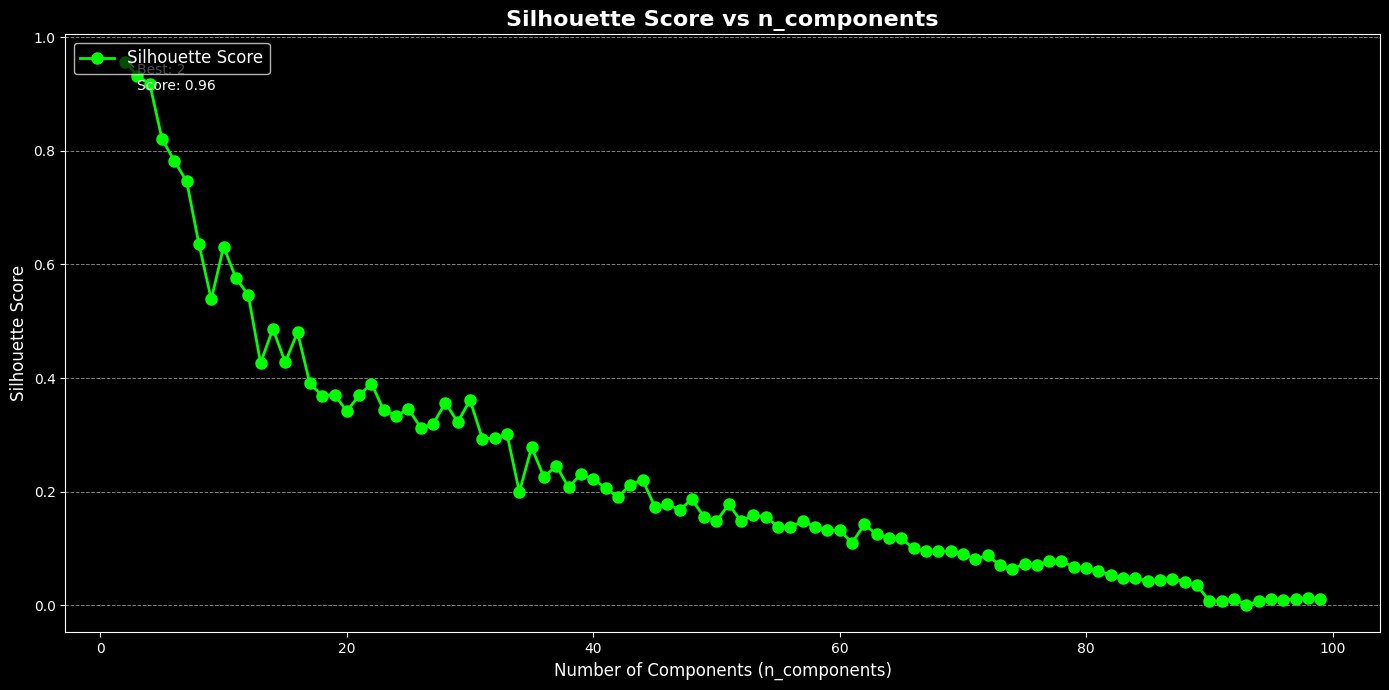

In [96]:
import matplotlib.pyplot as plt

# Data untuk plotting
n_components = list(results.keys())
silhouette_scores = [metrics['silhouette'] for metrics in results.values()]

# Ganti dengan style bawaan yang mirip
plt.style.use("dark_background")

# Membuat figure dengan nuansa grafik trading
plt.figure(figsize=(14, 7))

# Plot garis dengan marker
plt.plot(n_components, silhouette_scores, label="Silhouette Score", color="lime", linewidth=2, marker="o", markersize=8)

# Menambahkan grid horizontal
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

# Menambahkan judul dan label
plt.title("Silhouette Score vs n_components", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Number of Components (n_components)", fontsize=12, color="white")
plt.ylabel("Silhouette Score", fontsize=12, color="white")

# Menambahkan anotasi untuk nilai maksimum
max_score = max(silhouette_scores)
best_n = n_components[silhouette_scores.index(max_score)]
plt.annotate(f"Best: {best_n}\nScore: {max_score:.2f}",
             xy=(best_n, max_score), xytext=(best_n + 1, max_score - 0.05),
             arrowprops=dict(facecolor='red', arrowstyle="->"),
             fontsize=10, color="white")

# Menambahkan legenda
plt.legend(fontsize=12, loc="upper left", facecolor="black", edgecolor="white", framealpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

# Clustering

Silhouette Score: 0.0350
Jumlah data pada setiap cluster:
Cluster
0    52
1    48
Name: count, dtype: int64


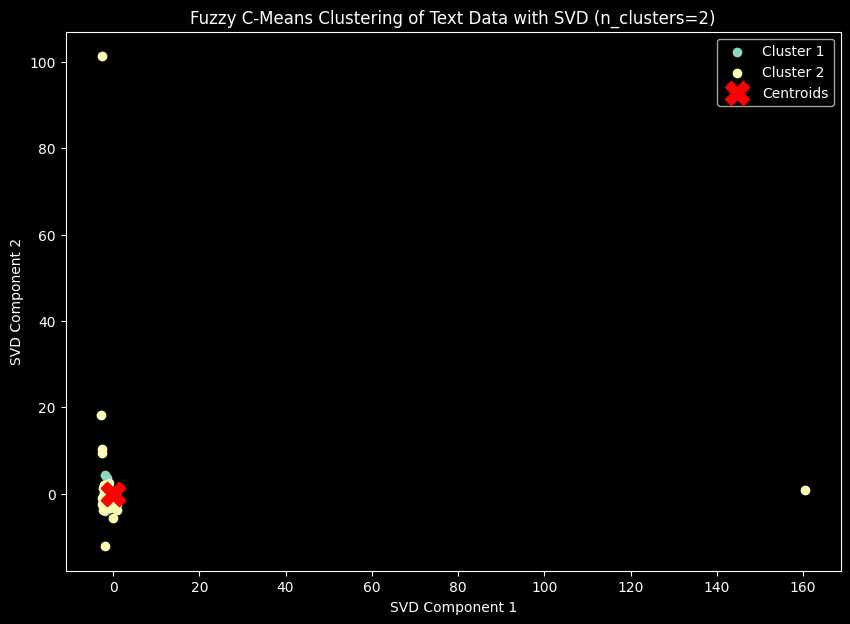

In [97]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Untuk manipulasi DataFrame

df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas-PPWA/Hasil_Prepros.csv")
data = df['stopword_removal']
random_seed = 42  # Tetapkan seed untuk konsistensi

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
tfidf = tfidf_matrix.toarray()

#Step 3 Normalisasi Hasil TF-IDF
scaler = StandardScaler()
data_normalisasi = scaler.fit_transform(tfidf)

# Step 4 : Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components= 89 , random_state=random_seed)
data_cluster = svd.fit_transform(data_normalisasi)



# Fuzzy C-Means Clustering
n_clusters = 2
fcm = FCM(n_clusters=n_clusters, m=2.0, max_iter=1000, epsilon=0.001, random_state=random_seed)
fcm.fit(data_cluster)

# Mendapatkan hasil clustering
membership = fcm.u
cluster_labels = np.argmax(membership, axis=1)  # Menentukan cluster untuk setiap data
# Tambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
# Tampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
# Tambahkan setelah cluster_labels dihasilkan
silhouette_avg = silhouette_score(data_cluster, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Cetak hasil jumlah data per cluster
print("Jumlah data pada setiap cluster:")
print(cluster_counts)


# Visualisasi hasil clustering
plt.figure(figsize=(10, 7))

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    plt.scatter(data_cluster[cluster_labels == i, 0],
                data_cluster[cluster_labels == i, 1], label=f'Cluster {i+1}')

# Plot centroid
cluster_centers = fcm.centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [98]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
df

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal,Cluster
0,"Nunggak 8 Bulan, Segini Pajak Ford Mustang Mil...","Kamis, 19 Sep 2024 13:05 WIB",Jakarta - Bareskrim Polri menyita aset senilai...,Otomotif,Jakarta Bareskrim Polri menyita aset senilai ...,jakarta bareskrim polri menyita aset senilai ...,"['jakarta', 'bareskrim', 'polri', 'menyita', '...",jakarta bareskrim polri menyita aset senilai r...,0
1,Bos Ford Kaget usai Jajal Mobil China: Mereka ...,"Kamis, 19 Sep 2024 12:33 WIB","Jakarta - Chief Executive Officer (CEO) Ford, ...",Otomotif,Jakarta Chief Executive Officer CEO Ford Jim ...,jakarta chief executive officer ceo ford jim ...,"['jakarta', 'chief', 'executive', 'officer', '...",jakarta chief executive officer ceo ford jim f...,0
2,"Tarif Tol Dalam Kota Naik Jadi Segini, Berlaku...","Kamis, 19 Sep 2024 12:08 WIB",Jakarta - Jasa Marga mengumumkan kenaikan tari...,Otomotif,Jakarta Jasa Marga mengumumkan kenaikan tarif...,jakarta jasa marga mengumumkan kenaikan tarif...,"['jakarta', 'jasa', 'marga', 'mengumumkan', 'k...",jakarta jasa marga mengumumkan kenaikan tarif ...,0
3,Pak RT Aleix Espargaro Tak Sabar Balapan Terak...,"Kamis, 19 Sep 2024 11:40 WIB","Jakarta - Pebalap Aprilia asal Spanyol, Aleix ...",Otomotif,Jakarta Pebalap Aprilia asal Spanyol Aleix Es...,jakarta pebalap aprilia asal spanyol aleix es...,"['jakarta', 'pebalap', 'aprilia', 'asal', 'spa...",jakarta pebalap aprilia spanyol aleix espargar...,0
4,Angkot Listrik Bakal Diuji Coba di Jakarta,"Kamis, 19 Sep 2024 11:18 WIB",Jakarta - PT Transportasi Jakarta (TransJakart...,Otomotif,Jakarta PT Transportasi Jakarta TransJakarta ...,jakarta pt transportasi jakarta transjakarta ...,"['jakarta', 'pt', 'transportasi', 'jakarta', '...",jakarta pt transportasi jakarta transjakarta k...,0
...,...,...,...,...,...,...,...,...,...
95,Suku Bunga BI Dipangkas Jadi 6% Dinilai Berani,"Rabu, 18 Sep 2024 21:15 WIB",Jakarta - Bank Indonesia (BI) memutuskan untuk...,Keuangan,Jakarta Bank Indonesia BI memutuskan untuk me...,jakarta bank indonesia bi memutuskan untuk me...,"['jakarta', 'bank', 'indonesia', 'bi', 'memutu...",jakarta bank indonesia bi memutuskan menurunka...,0
96,Prabowo Ingatkan Perang Makin Marak hingga Sal...,"Rabu, 18 Sep 2024 21:00 WIB",Jakarta - Presiden terpilih Prabowo Subianto m...,Keuangan,Jakarta Presiden terpilih Prabowo Subianto me...,jakarta presiden terpilih prabowo subianto me...,"['jakarta', 'presiden', 'terpilih', 'prabowo',...",jakarta presiden terpilih prabowo subianto men...,1
97,"Ditjen Pajak Respons Kabar 6 Juta NPWP Bocor, ...","Rabu, 18 Sep 2024 20:36 WIB",Jakarta - Direktorat Jenderal Pajak (DJP) Keme...,Keuangan,Jakarta Direktorat Jenderal Pajak DJP Kemente...,jakarta direktorat jenderal pajak djp kemente...,"['jakarta', 'direktorat', 'jenderal', 'pajak',...",jakarta direktorat jenderal pajak djp kementer...,0
98,Buruh Waswas Kisruh di Kadin Pengaruhi Penetap...,"Rabu, 18 Sep 2024 20:30 WIB",Jakarta - Presiden Partai Buruh yang juga Pres...,Keuangan,Jakarta Presiden Partai Buruh yang juga Presi...,jakarta presiden partai buruh yang juga presi...,"['jakarta', 'presiden', 'partai', 'buruh', 'ya...",jakarta presiden partai buruh presiden konfede...,0


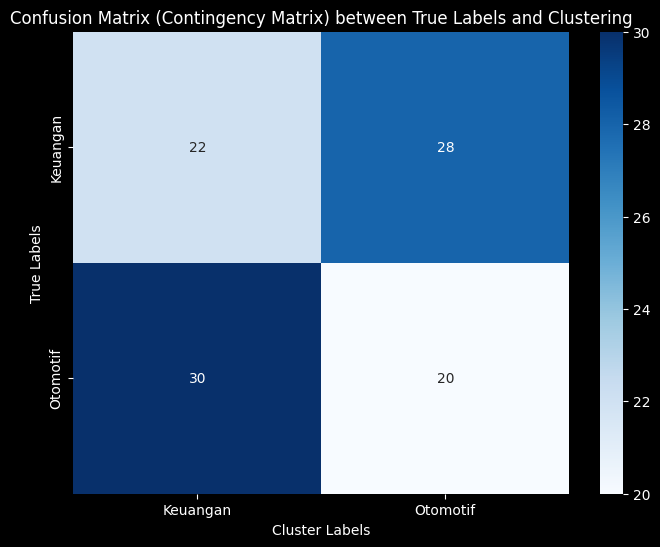

Confusion Matrix (Contingency Matrix):
[[22 28]
 [30 20]]


In [99]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil kolom kategori dari dataframe sebagai label asli (true labels)
true_labels = df['kategori']  # Ganti 'kategori' dengan nama kolom kategori di DataFrame Anda

# Gunakan LabelEncoder untuk mengubah kategori menjadi angka
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(true_labels)

# Hitung confusion matrix antara true labels dan hasil clustering
conf_matrix = confusion_matrix(true_labels_encoded, cluster_labels)

# Tampilkan confusion matrix menggunakan heatmap untuk visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Contingency Matrix) between True Labels and Clustering')
plt.xlabel('Cluster Labels')
plt.ylabel('True Labels')
plt.show()

# Cetak confusion matrix secara numerik
print("Confusion Matrix (Contingency Matrix):")
print(conf_matrix)

In [100]:
# Tambahkan kolom ID jika belum ada
df['id'] = df.index

# Ambil kolom id, kategori, dan Cluster # Changed 'kategori_encoded' to 'kategori'
selected_columns = df[['id', 'kategori', 'Cluster']]

# Tampilkan DataFrame yang hanya berisi kolom yang dipilih
print(selected_columns)

# Ambil semua anggota Cluster 0
cluster_0 = selected_columns[selected_columns['Cluster'] == 0]['id'].tolist()

# Ambil semua anggota Cluster 1
cluster_1 = selected_columns[selected_columns['Cluster'] == 1]['id'].tolist()

# Tampilkan hasil dalam bentuk list
print("Anggota Cluster 0:", cluster_0)
print("Anggota Cluster 1:", cluster_1)

    id  kategori  Cluster
0    0  Otomotif        0
1    1  Otomotif        0
2    2  Otomotif        0
3    3  Otomotif        0
4    4  Otomotif        0
..  ..       ...      ...
95  95  Keuangan        0
96  96  Keuangan        1
97  97  Keuangan        0
98  98  Keuangan        0
99  99  Keuangan        1

[100 rows x 3 columns]
Anggota Cluster 0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 14, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 30, 33, 36, 40, 44, 46, 47, 48, 50, 51, 52, 53, 54, 56, 57, 59, 60, 63, 65, 71, 74, 78, 85, 86, 87, 90, 91, 95, 97, 98]
Anggota Cluster 1: [10, 11, 13, 15, 18, 20, 24, 29, 31, 32, 34, 35, 37, 38, 39, 41, 42, 43, 45, 49, 55, 58, 61, 62, 64, 66, 67, 68, 69, 70, 72, 73, 75, 76, 77, 79, 80, 81, 82, 83, 84, 88, 89, 92, 93, 94, 96, 99]


In [101]:
from sklearn.metrics import silhouette_score
import numpy as np

# Mengonversi keanggotaan fuzzy menjadi label cluster dengan memilih cluster dengan membership tertinggi
fuzzy_labels = np.argmax(membership, axis=1)

# Menghitung Silhouette Score
silhouette_avg = silhouette_score(data_cluster, fuzzy_labels)

# Menampilkan Silhouette Score
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.0350


In [102]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
import joblib
import pandas as pd

# Membaca data
df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas-PPWA/Hasil_Prepros.csv")
data = df['stopword_removal'].astype(str)  # Pastikan data berupa string

# Fungsi untuk menerapkan FCM dalam pipeline
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,         # Jumlah cluster yang diinginkan
        m=2.0,                # Fuzziness coefficient
        max_iter=1000,        # Maksimal iterasi
        epsilon=0.001,        # Toleransi konvergensi
        random_state=42       # Menetapkan seed untuk random state
    )
    fcm.fit(X)
    return fcm

# Fungsi pembungkus untuk FCM (untuk FunctionTransformer)
def fit_fcm_wrapper(X):
    return fit_fcm(X)

# Tuning parameter TfidfVectorizer
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.8, min_df=2, ngram_range=(1, 2))),
    ('scaler', StandardScaler(with_mean=False)),
    ('svd', TruncatedSVD(n_components=20)),
    ('fcm', FunctionTransformer(func=fit_fcm_wrapper))
])

# Fit pipeline pada data pelatihan
pipeline.fit(data)

# Simpan pipeline yang telah dilatih
joblib.dump(pipeline, 'svd_tfidf_scaler_fcm_pipeline.pkl')

['svd_tfidf_scaler_fcm_pipeline.pkl']

In [103]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
import numpy as np
import pandas as pd

# 1. Memuat pipeline yang sudah dilatih sebelumnya
pipeline = joblib.load('svd_tfidf_scaler_fcm_pipeline.pkl')

# 2. Melakukan FCM pada data pelatihan (sudah dilabeli Games dan Sepakbola)
df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas-PPWA/Hasil_Prepros.csv")
data_pelatihan = df['stopword_removal']

# Transformasi data pelatihan menggunakan pipeline
X_train_transformed = pipeline[:-1].transform(data_pelatihan)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

# 3. Melakukan clustering FCM pada data pelatihan
fcm_model = FCM(n_clusters=2, m=2.0, max_iter=1000, epsilon=0.001, random_state=42)
fcm_model.fit(X_train_transformed)

# 4. Menyelaraskan cluster dengan label yang diketahui
labels_train = df['kategori']

# Menyelaraskan cluster dengan label
cluster_labels = fcm_model.predict(X_train_transformed)
cluster_to_label = {0: 'Otomotif', 1: 'Keuangan'}


# Menyelaraskan prediksi cluster dengan label
predicted_labels = [cluster_to_label[cluster] for cluster in cluster_labels]

# 5. Memuat data baru untuk prediksi
teks_baru = """Jakarta - Bank Sentral Amerika Serikat (AS) The Federal Reserve (The Fed) akhirnya memangkas suku bunga acuan sebesar 50 basis poin (bps) menjadi 4,75-5%. Momentum ini banyak ditunggu karena yang pertama sejak Maret 2020 atau empat tahun lalu saat awal pandemi COVID-19. Pemangkasan sebesar 50 bps lebih besar dari ekspektasi pasar yang memperkirakan 25 bps. Keputusan ini diambil dalam upaya untuk mencegah perlambatan di pasar tenaga kerja dan meyakini inflasi AS sudah bergerak dalam kisaran. "Komite telah memperoleh keyakinan yang lebih besar bahwa inflasi bergerak secara berkelanjutan menuju 2% dan menilai bahwa risiko untuk mencapai sasaran ketenagakerjaan dan inflasi seimbang," kata The Fed dikutip dari CNBC, Kamis (19/9/2024). Komite mengindikasikan melalui dot plot-nya setara dengan 50 bps pemotongan lagi pada akhir tahun, mendekati harga pasar. Matriks ekspektasi masing-masing pejabat menunjukkan adanya satu poin persentase penuh dalam pemangkasan pada akhir tahun 2025 dan satu setengah poin pada tahun 2026. Perdagangan bergejolak setelah keputusan tersebut dengan Dow Jones Industrial Average melonjak sebanyak 375 poin setelah dirilis, sebelum sedikit mereda karena investor mencerna berita tersebut dan mempertimbangkan apa yang ditunjukkannya tentang keadaan ekonomi. Pejabat The Fed menaikkan tingkat pengangguran tahun ini menjadi 4,4%, dari proyeksi 4% pada pembaruan terakhir di Juni 2024 dan menurunkan prospek inflasi menjadi 2,3% dari 2,6% sebelumnya. Mengenai inflasi inti, komite menurunkan proyeksinya menjadi 2,6%, penurunan 0,2 poin persentase dari Juni 2024. The Fed dalam beberapa hari terakhir telah menyatakan kekhawatiran tentang pasar tenaga kerja. Pemutusan hubungan kerja (PHK) tidak menunjukkan tanda-tanda pemulihan, hingga perekrutan telah melambat secara signifikan. Simak Video: Jaga Stabilitas, BI Tahan Suku Bunga [Gambas:Video 20detik] (aid/kil)"""
# Transformasi data baru menggunakan pipeline
X_new_transformed = pipeline[:-1].transform([teks_baru])
if hasattr(X_new_transformed, 'toarray'):
    X_new_transformed = X_new_transformed.toarray()

# 6. Prediksi cluster untuk data baru
cluster_new = fcm_model.predict(X_new_transformed)

# Menyelaraskan prediksi cluster dengan label
predicted_label_new = cluster_to_label[cluster_new[0]]

# 7. Menampilkan hasil
print(f"Teks baru ini diprediksi ke dalam cluster: {predicted_label_new}")


Teks baru ini diprediksi ke dalam cluster: Keuangan
